In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers

In [2]:
img_size=256
b_size=32
channels=3
epochs=50

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    shuffle=True,
    image_size= (img_size, img_size),
    batch_size=(b_size)
)

Found 2152 files belonging to 3 classes.


In [4]:
class_names=dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [5]:
for image_batch, label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())

(32, 256, 256, 3)
[0 0 0 1 2 1 1 1 0 1 1 1 0 0 1 0 1 1 1 0 1 1 0 1 1 0 1 1 0 2 1 0]


In [6]:
def get_dataset_partitions_tf(dataset, training_split=0.8, validation_split=0.1, testing_split=0.1, shuffle=True, shuffle_size=10000):
    
    dataset_size=len(dataset)
    if shuffle:
        dataset=dataset.shuffle(shuffle_size,seed=7)
    
    training_size = int(training_split*dataset_size)
    validation_size=int(validation_split*dataset_size)
    testing_size=int(testing_split*dataset_size)

    training_dataset=dataset.take(training_size)
    validation_dataset=dataset.skip(training_size).take(validation_size)
    testing_dataset=dataset.skip(training_size).skip(validation_size).take(testing_size)
    
    return training_dataset, validation_dataset, testing_dataset

In [7]:
training_dataset, validation_dataset, testing_dataset = get_dataset_partitions_tf(dataset)

In [8]:
training_dataset= training_dataset.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
#shuffle is used for randomizing images
#prefetch is used for better performance, when the GPU is used when the CPU is full
validation_dataset= validation_dataset.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
testing_dataset= testing_dataset.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [9]:
#during processing, if an image has a different size, it is going to be resized
resize_rescale= tf.keras.Sequential([
    tf.keras.layers.Resizing(img_size,img_size),
    tf.keras.layers.Rescaling(1.0/255)
])

In [10]:
#data augmentation is used to create more images than there actually are by applying filters
data_augmentation= tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
])

In [11]:
input_shape=(b_size, img_size, img_size, channels)
num_of_classes=3

model = models.Sequential([
    resize_rescale, 
    data_augmentation,
    
    #convonution layer=
    layers.Conv2D(32,kernel_size=(3,3), activation='relu',input_shape=input_shape),
    #32 is chosen after trying multiple sizes
    #3,3 is the actual filter size
    #'relu' is very fast to compute

    #pooling layer=
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    #flatten to get an array of neurons
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_of_classes, activation='softmax'),
])

model.build(input_shape=input_shape)

C:\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


In [12]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (32, 254, 254, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (32, 127, 127, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (32, 125, 125, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (32, 62, 62, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (32, 60, 60, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (32, 30, 30, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (32, 28, 28, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (32, 14, 14, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (32, 12544)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (32, 64)                    │         802,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (32, 3)                     │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 896,323 (3.42 MB)

 Trainable params: 896,323 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    #adam is a famous optimizer
    optimizer='adam',
    
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),

    #'accuracy' is used to track the training process
    metrics=['accuracy']
)

In [14]:
history= model.fit(
    training_dataset,
    epochs=epochs,
    batch_size=b_size,
    verbose=1,
    validation_data=validation_dataset
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.5024 - loss: 0.9566 - val_accuracy: 0.8021 - val_loss: 0.5877
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 52s 964ms/step - accuracy: 0.8494 - loss: 0.4624 - val_accuracy: 0.8125 - val_loss: 0.6064
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 53s 993ms/step - accuracy: 0.8481 - loss: 0.3466 - val_accuracy: 0.8490 - val_loss: 0.4674
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 53s 972ms/step - accuracy: 0.8822 - loss: 0.2910 - val_accuracy: 0.8854 - val_loss: 0.3343
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 47s 862ms/step - accuracy: 0.8794 - loss: 0.2968 - val_accuracy: 0.8594 - val_loss: 0.3279
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 48s 892ms/step - accuracy: 0.8884 - loss: 0.2842 - val_accuracy: 0.9115 - val_loss: 0.2069
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 46s 846ms/step - accuracy: 0.9469 - loss: 0.1448 - val_accuracy: 0.8594 - val_loss: 0.4132
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 46s 844ms/step - accuracy: 0.9240 - loss: 0.2020 - val_accura

In [15]:
scores = model.evaluate(testing_dataset)

6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 287ms/step - accuracy: 0.9178 - loss: 0.3134


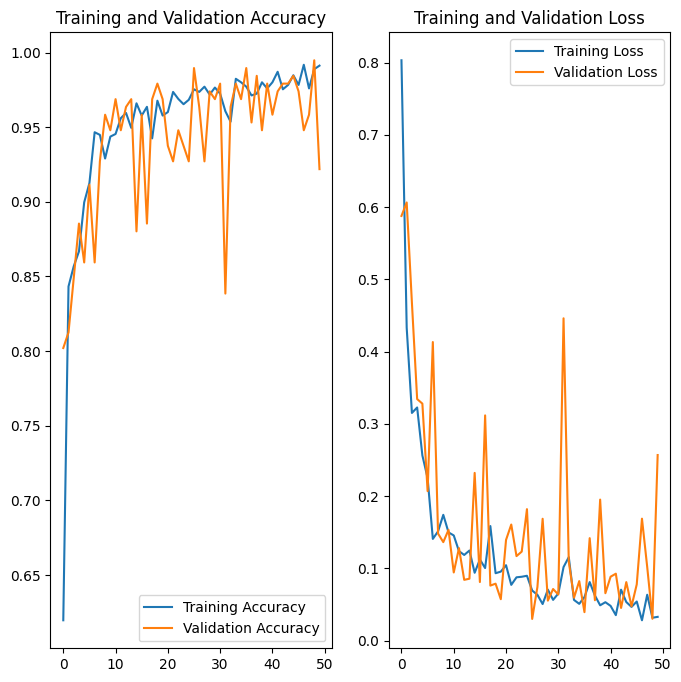

In [16]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [17]:
import os

# Verificăm dacă directorul există; dacă nu, îl creăm
if not os.path.exists("../models"):
    os.makedirs("../models")

# Filtrăm elementele care pot fi convertite în întregi
def is_int(s):
    try:
        int(s)
        return True
    except ValueError:
        return False

# Obținem numele directoarelor și fișierelor care pot fi convertite în întregi
valid_entries = [i.split('.')[0] for i in os.listdir("../models") if is_int(i.split('.')[0])]

# Calculăm noua versiune a modelului
model_version = max([int(i) for i in valid_entries] + [0]) + 1
model_dir = f"../models/{model_version}.keras"  # Definim calea directorului modelului

# Salvăm modelul
model.save(model_dir)


